In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tvb.datatypes.connectivity import Connectivity
from tvb.simulator.simulator import Simulator
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.coupling import Linear as LinearCoupling
from tvb.simulator.models.linear import Linear
from tvb.simulator.monitors import Raw
from tvb.contrib.simulator.models.polynomial import Polynomial, PolynomialCoupling


ORDER = 3
N_MODES = 2
N_NODES = 84


In [2]:
sim = Simulator()

In [3]:
sim.connectivity = Connectivity.from_file()
sim.connectivity.tract_lengths *=0
sim.connectivity.configure()
Nregs = sim.connectivity.number_of_regions
sim.connectivity.weights = np.ones((Nregs, Nregs))
jj = np.arange(Nregs).astype("i")
sim.connectivity.weights[jj, jj] = 0.0
sim.connectivity.configure()

2025-09-29 14:24:19,289 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


In [4]:
# c_lin_coeff = 1.0
# sim.coupling = LinearCoupling(a=np.array([c_lin_coeff])) # 
# sim.coupling = PolynomialCoupling(p=np.array([[0.0, c_lin_coeff, 0.1, 0.1]]))
p=np.random.normal(size=(Nregs, Nregs, N_MODES, ORDER+1))
pdiag = np.einsum("jj...->j...", p)
assert pdiag.shape == (Nregs, N_MODES, ORDER+1)
p[jj, jj] = 0.0
assert np.all(p[jj, jj] == 0)
sim.coupling = PolynomialCoupling(p=p)

In [5]:
pdiag.shape

(76, 2, 4)

In [6]:
# scale = 1.0
# m_lin_coeff = -1.0
# sim.model = Linear(gamma=np.array([scale*m_lin_coeff]))
# sim.model = Polynomial(lamda=np.array([scale]), p=np.array([0.0, m_lin_coeff, 0.1, 0.1]))
sim.model = Polynomial(p=pdiag)
sim.model.number_of_modes = N_MODES
# sim.model.configure()

In [7]:
sim.model.configure()

In [8]:
# sim.integrator = HeunStochastic(dt=0.1)
sim.integrator.dt = 0.1
# sim.integrator.nsig = 0.000001

In [9]:
sim.monitors = (Raw(), )

In [10]:
sim.simulation_length = 0.2

In [11]:
sim.initial_conditions = np.ones((1, ORDER, Nregs, N_MODES))

In [12]:
sim.configure()

In [13]:
# sim.coupling.p.shape

In [14]:
results = sim.run()

2025-09-29 14:24:19,395 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


In [15]:
[sim.model.state_variable_dfuns, sim.model.parameter_names, 
 sim.model.state_variables, sim.model.non_integrated_variables, 
 sim.model.state_variable_range, sim.model.variables_of_interest,
 sim.model.state_variable_mask,
 sim.model._nvar, sim.model.cvar]

[{'x': 'lamda * (p0 + p1*x + p2*x^2 + p3*x^3)'},
 ('lamda', 'p', 'p0', 'p1', 'p2', 'p3'),
 ('x', 'x2', 'x3'),
 ('x2', 'x3'),
 {'x': array([-1,  1]), 'x2': array([0, 1]), 'x3': array([-1,  1])},
 ('x',),
 array([ True, False, False]),
 3,
 array([0, 1, 2], dtype=int32)]

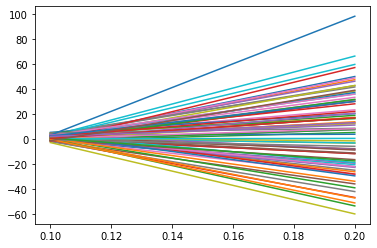

In [16]:
plt.plot(results[0][0], results[0][1][:, :, :, 0].squeeze());

In [17]:
from tvb.contrib.tests.model.model_test import TestPolynomialModel
test = TestPolynomialModel()
test.test_polynomial_model()

2025-09-29 14:24:19,576 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-29 14:24:19,582 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2025-09-29 14:24:19,585 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-29 14:24:19,591 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2025-09-29 14:24:19,594 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-29 14:24:19,601 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2025-09-29 14:24:19,604 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-29 14:24:19,610 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2025-09-29 14:24:19,613 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2025-09-29 14:24:19,619 - WARNING - tvb.simulator.integrators - ran

/home/docker/packages/tvb-root/tvb_library/tvb/simulator/history.py:204: RuntimeWarning: overflow encountered in cast
  self.buffer[step % self.n_time] = new_state[self.cvars]
/home/docker/packages/tvb-root/tvb_library/tvb/simulator/coupling.py:166: RuntimeWarning: overflow encountered in cast
  sum[:, nzr] = numpy.add.reduceat(weights_col * pre, lri, axis=1)
